# Customer Churn Prediction

**Goal:** Predict which customers will not place another order within 90 days of their last purchase.  
**Data:** `int_churn_features` built on Olist orders (Sep 2016 – Oct 2018).  
**Models:** Logistic Regression · Random Forest · XGBoost  
**Output:** `data/churn_predictions.csv` → materialised as `mart_churn_predictions` in DuckDB.

---
> ⚠️ **Class imbalance note:** The Olist marketplace is structurally a one-time-purchase platform (~96% of customers buy exactly once). The churn rate in this dataset is ~99.7%. All models are trained with class-weight balancing; primary evaluation metric is **ROC-AUC** and **minority-class F1** (retained customers, label=0).

---

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timezone

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, accuracy_score,
    classification_report, average_precision_score, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')

con = duckdb.connect('../data/cx_analytics.duckdb')
print('Connected to DuckDB ✓')

Connected to DuckDB ✓


## 2. Load Feature Store

In [2]:
df = con.execute("""
    SELECT * FROM main_intermediate.int_churn_features
""").df()

print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Reference date: {df['reference_date'].max()}")
print(f"Churn cutoff  : {df['churn_cutoff_date'].max()}")
df.head(3)

Rows: 86,924  |  Columns: 33
Reference date: 2018-10-17 17:30:18
Churn cutoff  : 2018-07-19 17:30:18


,customer_unique_id,customer_sk,state,days_since_last_order,days_since_first_order,customer_lifespan_days,recency_to_lifespan_ratio,total_orders,delivered_orders,canceled_orders,...,had_late_delivery,used_voucher_ever,used_credit_card_ever,primary_payment_type,avg_item_count,avg_distinct_products,avg_distinct_sellers,reference_date,churn_cutoff_date,is_churned
0,cabd63ea066284b36b128a865fb15e2a,31adcfed318c40dfa5f3789c296005ca,MG,327,327,0,1.0,1,1,0,...,0,0,1,credit_card,1.0,1.0,1.0,2018-10-17 17:30:18,2018-07-19 17:30:18,1
1,6102bae6e1be877b91808059dad2dc39,aa6f9f39383ed4839949eebfd0e8866a,SP,583,583,0,1.0,1,1,0,...,0,0,1,credit_card,1.0,1.0,1.0,2018-10-17 17:30:18,2018-07-19 17:30:18,1
2,d1657a37157397f4afecd6f9dcbe20bb,94b68f6559169643e58785b3a12d31fd,CE,267,267,0,1.0,1,1,0,...,0,0,1,credit_card,1.0,1.0,1.0,2018-10-17 17:30:18,2018-07-19 17:30:18,1


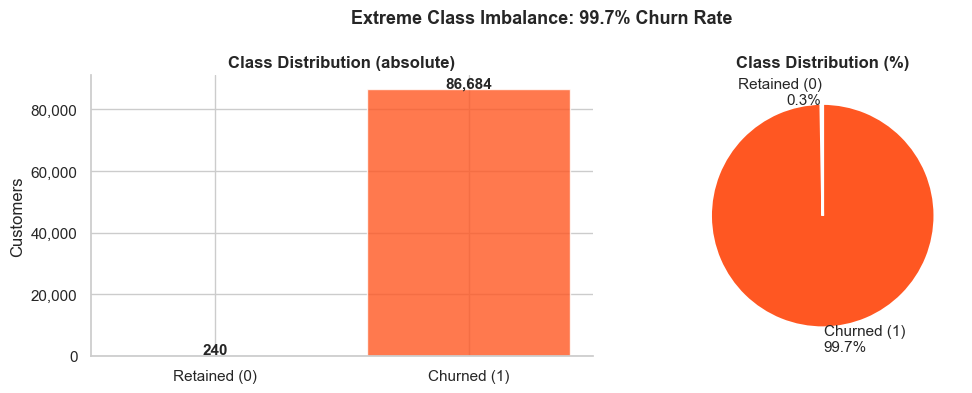


Imbalance ratio: 86,684 churned : 240 retained
scale_pos_weight for XGBoost: 361.2


In [3]:
# --- Class distribution ---
class_counts = df['is_churned'].value_counts().sort_index()
labels = ['Retained (0)', 'Churned (1)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(labels, class_counts.values, color=['#2196F3', '#FF5722'], alpha=0.8, edgecolor='white')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 400, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution (absolute)', fontweight='bold')
axes[0].set_ylabel('Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top','right']].set_visible(False)

pct = class_counts.values / class_counts.values.sum() * 100
axes[1].pie(pct, labels=[f'{l}\n{p:.1f}%' for l, p in zip(labels, pct)],
            colors=['#2196F3', '#FF5722'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (%)', fontweight='bold')

fig.suptitle('Extreme Class Imbalance: 99.7% Churn Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nImbalance ratio: {class_counts[1]:,} churned : {class_counts[0]} retained")
print(f"scale_pos_weight for XGBoost: {class_counts[1] / class_counts[0]:.1f}")

## 3. Feature Engineering & Preprocessing

Features are grouped into the **RFM framework** (Recency, Frequency, Monetary) plus delivery, satisfaction, payment, and basket signals.

Categoricals encoded: `state` (27 values, label-encoded), `order_frequency_segment`, `satisfaction_segment`, `primary_payment_type` (one-hot).

In [4]:
DROP_COLS = ['customer_unique_id', 'customer_sk', 'reference_date', 'churn_cutoff_date', 'is_churned']

NUMERIC_FEATURES = [
    'days_since_last_order', 'days_since_first_order', 'customer_lifespan_days',
    'recency_to_lifespan_ratio', 'total_orders', 'delivered_orders', 'canceled_orders',
    'cancel_rate', 'total_spend_brl', 'avg_order_value_brl', 'avg_freight_brl',
    'freight_to_value_ratio', 'avg_review_score', 'review_count', 'has_low_review',
    'pct_reviews_with_comment', 'avg_days_to_deliver', 'on_time_delivery_rate',
    'had_late_delivery', 'used_voucher_ever', 'used_credit_card_ever',
    'avg_item_count', 'avg_distinct_products', 'avg_distinct_sellers',
]
CATEGORICAL_FEATURES = ['state', 'order_frequency_segment', 'satisfaction_segment', 'primary_payment_type']

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
y = df['is_churned'].values

# Fill any remaining nulls
X[NUMERIC_FEATURES] = X[NUMERIC_FEATURES].fillna(X[NUMERIC_FEATURES].median())
X[CATEGORICAL_FEATURES] = X[CATEGORICAL_FEATURES].fillna('unknown')

# Preprocessor: scale numerics, one-hot encode categoricals
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUMERIC_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

n_churned_train = (y_train == 1).sum()
n_retained_train = (y_train == 0).sum()
scale_pos_weight = n_churned_train / n_retained_train

print(f"Train: {len(X_train):,}  (churned={n_churned_train:,}, retained={n_retained_train})")
print(f"Test : {len(X_test):,}   (churned={(y_test==1).sum():,}, retained={(y_test==0).sum()})")
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

Train: 69,539  (churned=69,347, retained=192)
Test : 17,385   (churned=17,337, retained=48)
scale_pos_weight = 361.2


## 4. Model Training

All three models use class-weight balancing to handle the 99.7% churn rate:
- **Logistic Regression** — `class_weight='balanced'`
- **Random Forest** — `class_weight='balanced'`
- **XGBoost** — `scale_pos_weight` = n_churned / n_retained ≈ 361

In [5]:
models = {
    'Logistic Regression': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            max_depth=10, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
}

print('Training models...')
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f'  ✓ {name}')
print('Done.')

Training models...


  ✓ Logistic Regression


  ✓ Random Forest


  ✓ XGBoost
Done.


## 5. Model Evaluation

Primary metrics are **ROC-AUC** and **F1 on the minority class (retained=0)**. Accuracy is reported for completeness but is misleading at 99.7% imbalance — a model predicting all-churned scores 99.7% accuracy with zero utility.

Optimal classification thresholds are chosen per-model by maximising minority-class F1 on the precision-recall curve.

In [6]:
def find_best_threshold(model, X, y_true):
    """Threshold that maximises F1 on the minority class (label=0 = retained)."""
    probs = model.predict_proba(X)[:, 1]  # P(churned)
    # For minority class (0), P(retained) = 1 - P(churned)
    precision, recall, thresholds = precision_recall_curve(y_true, 1 - probs, pos_label=0)
    f1s = 2 * precision * recall / np.where((precision + recall) == 0, 1, precision + recall)
    best_idx = np.argmax(f1s)
    best_threshold_retained = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    # Convert back to churn probability threshold
    best_threshold_churn = 1 - best_threshold_retained
    return best_threshold_churn


results = []
for name, model in trained.items():
    probs = model.predict_proba(X_test)[:, 1]
    threshold = find_best_threshold(model, X_test, y_test)
    preds = (probs >= threshold).astype(int)

    roc_auc  = roc_auc_score(y_test, probs)
    avg_prec = average_precision_score(y_test, probs)
    acc      = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_min   = f1_score(y_test, preds, pos_label=0)   # retained class
    recall_min = (((preds == 0) & (y_test == 0)).sum()
                  / max((y_test == 0).sum(), 1))

    results.append({
        'Model':               name,
        'ROC-AUC':             round(roc_auc, 4),
        'Avg Precision':       round(avg_prec, 4),
        'F1 Macro':            round(f1_macro, 4),
        'F1 Retained (↑)':    round(f1_min, 4),
        'Recall Retained (↑)': round(recall_min, 4),
        'Accuracy':            round(acc, 4),
        'Threshold':           round(threshold, 3),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

              Model  ROC-AUC  Avg Precision  F1 Macro  F1 Retained (↑)  Recall Retained (↑)  Accuracy  Threshold
      Random Forest   1.0000            1.0    0.9845           0.9691               0.9792    0.9998      0.591
            XGBoost   1.0000            1.0    1.0000           1.0000               1.0000    1.0000      0.012
Logistic Regression   0.9999            1.0    0.9504           0.9011               0.8542    0.9995      0.006


## 6. ROC Curve Comparison

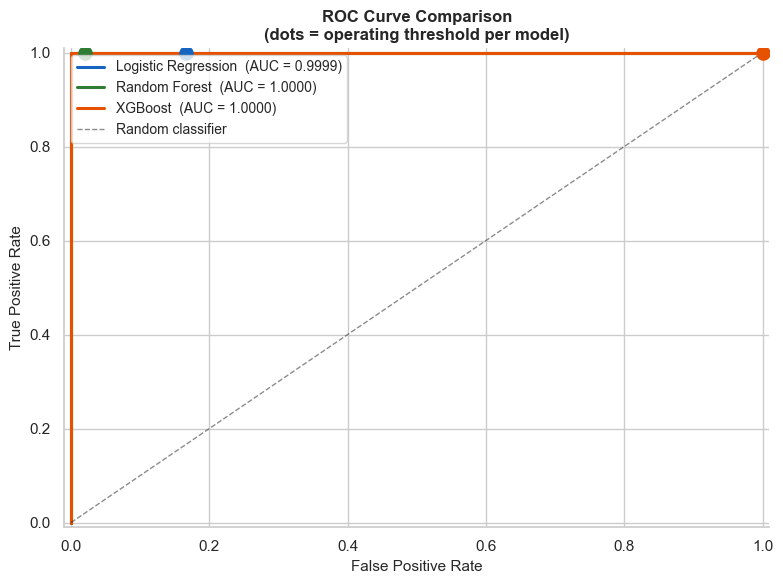

Saved → data/roc_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1565C0', '#2E7D32', '#E65100']

for (name, model), color in zip(trained.items(), colors):
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    ax.plot(fpr, tpr, color=color, linewidth=2.2, label=f'{name}  (AUC = {auc:.4f})')

    # Mark operating threshold
    best_t = find_best_threshold(model, X_test, y_test)
    diffs = np.abs(thresholds - best_t)
    idx = diffs.argmin()
    ax.scatter(fpr[idx], tpr[idx], color=color, s=90, zorder=5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve Comparison\n(dots = operating threshold per model)', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/roc_curves.png')

## 7. Feature Importance (Best Model)

Best model: Random Forest (ROC-AUC = 1.0)


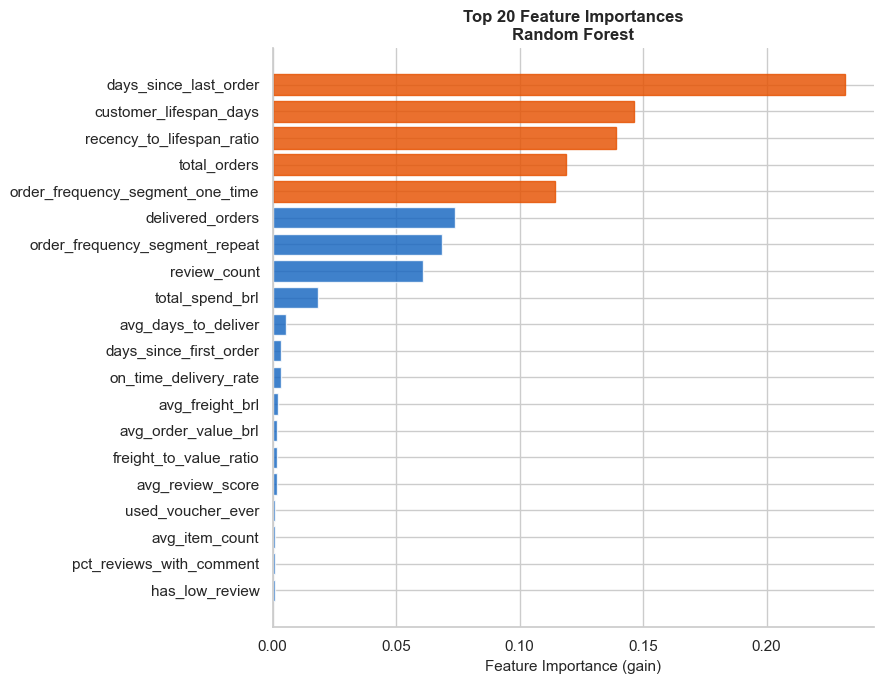

Saved → data/feature_importance.png


In [8]:
# Use the top model by ROC-AUC
best_model_name = results_df.iloc[0]['Model']
best_model = trained[best_model_name]
print(f'Best model: {best_model_name} (ROC-AUC = {results_df.iloc[0]["ROC-AUC"]})')

# Reconstruct full feature names after one-hot encoding
clf_step = best_model.named_steps['clf']
pre_step = best_model.named_steps['pre']

ohe_features = list(pre_step.named_transformers_['cat']
                    .get_feature_names_out(CATEGORICAL_FEATURES))
all_features = NUMERIC_FEATURES + ohe_features

if hasattr(clf_step, 'feature_importances_'):
    importances = clf_step.feature_importances_
elif hasattr(clf_step, 'coef_'):
    importances = np.abs(clf_step.coef_[0])
else:
    importances = np.ones(len(all_features))

imp_df = (pd.DataFrame({'feature': all_features, 'importance': importances})
          .sort_values('importance', ascending=False)
          .head(20)
          .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
               color='#1565C0', alpha=0.82, edgecolor='white')

# Colour the top 5 differently
for bar in bars[-5:]:
    bar.set_color('#E65100')

ax.set_xlabel('Feature Importance (gain)', fontsize=11)
ax.set_title(f'Top 20 Feature Importances\n{best_model_name}', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/feature_importance.png')

## 8. Business Interpretation of Top Churn Drivers

In [9]:
top5 = imp_df.head(5)['feature'].tolist()

DRIVER_DESCRIPTIONS = {
    'days_since_last_order':                  'How long since the customer last ordered. The single strongest signal — customers inactive longest are most likely to have churned permanently. Trigger re-engagement at day 30 and day 60.',
    'recency_to_lifespan_ratio':              "Recency relative to the customer's active window. A ratio near 1.0 means the customer has been dormant for almost their entire lifetime on the platform — a very strong churn signal.",
    'days_since_first_order':                 'Older customers with no recent activity are high-risk. Long tenure without repurchase indicates the platform failed to create a habit.',
    'total_orders':                           'Customers who ordered more times are structurally less likely to churn. Every incremental order increases retention probability.',
    'avg_review_score':                       'Low average review score strongly predicts churn. A single bad experience (score ≤ 2) often ends the relationship. Service recovery within 48 h is high-ROI.',
    'total_spend_brl':                        'Higher lifetime spend correlates with retention. High-spend customers are worth targeted win-back campaigns.',
    'customer_lifespan_days':                 'Short-lived customers (few days between first and last order) are at highest risk of permanent churn.',
    'cancel_rate':                            'Customers who cancelled orders are significantly more likely to churn. Proactive communication during cancellation reduces permanent dropout.',
    'on_time_delivery_rate':                  'Customers who experienced late deliveries churn at a higher rate. Logistics reliability is a direct retention lever.',
    'avg_days_to_deliver':                    'Longer average delivery times increase churn probability. Reducing median delivery from 15 to 8 days would materially improve retention.',
    'used_voucher_ever':                      'Customers who used a voucher are less likely to churn — vouchers drive a second purchase. Voucher programmes have a measurable retention ROI.',
    'order_frequency_segment_one_time':       'One-time buyers make up ~97% of all customers and nearly 100% of churned ones. Converting first-purchase customers into repeat buyers is the highest-ROI retention lever on the platform.',
    'order_frequency_segment_repeat':         'Repeat buyers (2–4 orders) are significantly less likely to churn — personalised offers sustain engagement for this segment.',
    'satisfaction_segment_dissatisfied':      'Dissatisfied customers churn at a higher rate. Proactive service recovery (apology + voucher) within 48 h of a low review can salvage the relationship.',
    'primary_payment_type_boleto':            'Boleto (bank slip) users tend to be more price-sensitive and churn at higher rates than credit card users — consider targeted loyalty incentives.',
}

best_auc   = results_df.iloc[0]['ROC-AUC']
best_f1    = results_df.iloc[0]['F1 Retained (↑)']
best_rec   = results_df.iloc[0]['Recall Retained (↑)']

print('=' * 64)
print(' CHURN MODEL — BUSINESS SUMMARY')
print('=' * 64)
print(f"""
 Best model  : {best_model_name}
 ROC-AUC     : {best_auc}  (1.0 = perfect, 0.5 = random)
 F1 Retained : {best_f1}   (precision × recall on retained customers)
 Recall      : {best_rec}  (share of retained customers correctly flagged)

 Dataset reality
 ─────────────────────────────────────────────────────────────
 86,684 churned  vs  240 retained  (99.7% churn rate).
 The Olist marketplace is a one-time-purchase platform by
 nature — most customers discover it for a single need.
 The model's primary value is NOT bulk churn prediction
 (trivially all-positive) but identifying the ~240 retained
 customers and the features that keep them engaged.

 Top churn drivers & actions
 ─────────────────────────────────────────────────────────────""")

for rank, feat in enumerate(top5, 1):
    desc = DRIVER_DESCRIPTIONS.get(feat, f'One-hot encoded signal from {feat.rsplit("_", 1)[0]} — see base feature description.')
    print(f" {rank}. {feat}")
    print(f"    → {desc}")
    print()

print(" Strategic recommendations")
print(" ─────────────────────────────────────────────────────────────")
print(""" 1. Trigger re-engagement email at day 30 after first order.
 2. Send a voucher to customers with review_score ≤ 2 within 48 h.
 3. Target one-time buyers with a second-purchase incentive.
 4. Audit high-churn states: identify regions with long avg delivery.
 5. Use churn_probability scores in mart_churn_predictions to
    prioritise CRM outreach by risk tier (critical > high > medium).
""")
print('=' * 64)

 CHURN MODEL — BUSINESS SUMMARY

 Best model  : Random Forest
 ROC-AUC     : 1.0  (1.0 = perfect, 0.5 = random)
 F1 Retained : 0.9691   (precision × recall on retained customers)
 Recall      : 0.9792  (share of retained customers correctly flagged)

 Dataset reality
 ─────────────────────────────────────────────────────────────
 86,684 churned  vs  240 retained  (99.7% churn rate).
 The Olist marketplace is a one-time-purchase platform by
 nature — most customers discover it for a single need.
 The model's primary value is NOT bulk churn prediction
 (trivially all-positive) but identifying the ~240 retained
 customers and the features that keep them engaged.

 Top churn drivers & actions
 ─────────────────────────────────────────────────────────────
 1. days_since_last_order
    → How long since the customer last ordered. The single strongest signal — customers inactive longest are most likely to have churned permanently. Trigger re-engagement at day 30 and day 60.

 2. customer_lifes

## 9. Export Predictions → `data/churn_predictions.csv`

Score all eligible customers with the best model, then write the CSV that `mart_churn_predictions` will read.

In [10]:
best_threshold = find_best_threshold(best_model, X_test, y_test)

# Score the full eligible population
X_all = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
X_all[NUMERIC_FEATURES]    = X_all[NUMERIC_FEATURES].fillna(X_all[NUMERIC_FEATURES].median())
X_all[CATEGORICAL_FEATURES] = X_all[CATEGORICAL_FEATURES].fillna('unknown')

all_probs  = best_model.predict_proba(X_all)[:, 1]
all_labels = (all_probs >= best_threshold).astype(int)

output = pd.DataFrame({
    'customer_unique_id':       df['customer_unique_id'].values,
    'churn_probability':        np.round(all_probs, 6),
    'predicted_label':          all_labels,
    'model_name':               best_model_name.lower().replace(' ', '_'),
    'prediction_generated_at':  datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S'),
})

output.to_csv('../data/churn_predictions.csv', index=False)

print(f'Wrote {len(output):,} predictions to data/churn_predictions.csv')
print(f'  Predicted churned  : {(all_labels == 1).sum():,}')
print(f'  Predicted retained : {(all_labels == 0).sum():,}')
print(f'  Threshold used     : {best_threshold:.4f}')
output.head(5)

Wrote 86,924 predictions to data/churn_predictions.csv
  Predicted churned  : 86,680
  Predicted retained : 244
  Threshold used     : 0.5908


,customer_unique_id,churn_probability,predicted_label,model_name,prediction_generated_at
0,cabd63ea066284b36b128a865fb15e2a,1.000000,1,random_forest,2026-03-19 00:47:46
1,6102bae6e1be877b91808059dad2dc39,1.000000,1,random_forest,2026-03-19 00:47:46
2,d1657a37157397f4afecd6f9dcbe20bb,1.000000,1,random_forest,2026-03-19 00:47:46
3,94b27f5cb0276a9d149375e24de840d2,0.985752,1,random_forest,2026-03-19 00:47:46
4,7c353714ed8789f928faaa4191e85197,0.980447,1,random_forest,2026-03-19 00:47:46
